In [1]:
# 1. 导入依赖的包
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pdb

warnings.filterwarnings('ignore')

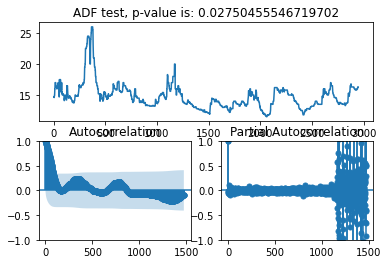

In [2]:
# 2. 准备数据
# 读取数据，并做可视化展示，以及一并绘制自相关、偏自相关图，还有平稳性检验。
def read_data():
    # file = '4_预测/ARIMA/in.xlsx'
    # df = pd.read_excel(file)
    df = pd.read_excel('/Users/bigcolour/Desktop/水产品价格预测/代码/new/4_预测/ARIMA/sarima_in.xlsx')

    ts = df.price

    return ts

def plot(ts):
    results = adfuller(ts)
    results_str = 'ADF test, p-value is: {}'.format(results[1])

    grid = plt.GridSpec(2, 2)
    ax1 = plt.subplot(grid[0, :])
    ax2 = plt.subplot(grid[1, 0])
    ax3 = plt.subplot(grid[1, 1])

    ax1.plot(ts)
    ax1.set_title(results_str)
    plot_acf(ts, lags=int(len(ts) / 2 - 1), ax=ax2)
    plot_pacf(ts, lags=int(len(ts) / 2 - 1), ax=ax3)
    plt.show()
    
ts = read_data()
plot(ts)

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                 2339
Model:                 ARIMA(4, 0, 4)   Log Likelihood                -754.707
Date:                Mon, 26 Jun 2023   AIC                           1529.414
Time:                        23:28:51   BIC                           1586.989
Sample:                             0   HQIC                          1550.387
                               - 2339                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0112      0.177      0.063      0.950      -0.336       0.359
ar.L1          1.0251      0.049     20.934      0.000       0.929       1.121
ar.L2         -0.2528      0.089     -2.840      0.0

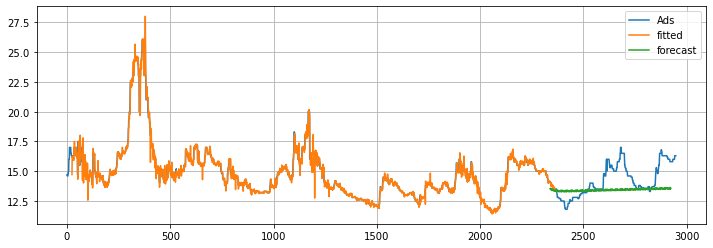

In [3]:
# 3. 模型验证（ARIMA版，手动进行季节差分）
# 先不直接上sarima，用arima先来个预热。
# 手动季节差分，将差分后的序列喂给模型，模型预测时再进行差分还原。
def find_pq(ts, d=0, max_p=5, max_q=5):
    best_p, best_q = 0, 0
    best_aic = np.inf

    for p in range(max_p):
        for q in range(max_q):
            model = ARIMA(ts, order=(p, d, q)).fit()
            aic = model.aic

            if aic < best_aic:
                best_aic = aic
                best_p = p
                best_q = q

    return best_p, best_q, best_aic

def version_arima_with_manual(ts):
    """
    ARIMA（手动季节差分）
    """
    # 周期大小
    periods = 24

    # 季节差分
    ts_diff = ts - ts.shift(periods)
    # 再次差分（季节差分后p值小于0.05-接近，可认为平稳，若要严格一点也可再做一次差分）
    # ts_diff = ts_diff - ts_diff.shift(1)

    # （训练数据中不能有缺失值，这里差分后前几个值为nan，故去除）
    ts_diff = ts_diff[~pd.isnull(ts_diff)]

    # 数据拆分
    train, test = train_test_split(ts_diff, train_size=0.8)

    # 模型训练（训练数据为差分后的数据-已平稳，所以d=0）
    p, q, _ = find_pq(train)
    model = ARIMA(train, order=(p, 0, q)).fit()
    print(model.summary())

    # 拟合结果
    fitted = model.fittedvalues

    # 模型预测
    fcst = model.forecast(test.shape[0])

    # 差分还原（拟合结果）
    fitted += ts.shift(periods)

    # 差分还原（预测结果）
    tmp = ts.loc[train.index].values.tolist() + fcst.values.tolist()
    for i in range(len(tmp) - fcst.shape[0], len(tmp)):
        tmp[i] += tmp[i - periods]
    fcst.loc[:] = tmp[-fcst.shape[0]:]

    # 模型评估
    rmse = np.sqrt(mean_squared_error(test, fcst))
    print('RMSE: %.4f' % rmse)

    # 可视化
    plt.figure(figsize=(12, 4))
    ts.plot(label='Ads')
    fitted.plot(label='fitted')
    fcst.plot(label='forecast')
    plt.legend()
    plt.grid(True)
    plt.show()
    
version_arima_with_manual(ts)

In [5]:
# 4. 模型验证（SARIMA版，网格搜索参数）
# 设置参数d=0，D=1，(p,q)(P,Q)网格搜索。
def find_pq_PQ(ts, m, d, D, max_p=5, max_q=5, max_P=2, max_Q=2):
    best_p, best_q = 0, 0
    best_P, best_Q = 0, 0
    best_aic = np.inf

    for p in range(max_p):
        for q in range(max_q):
            for P in range(max_P):
                for Q in range(max_Q):
                    model = SARIMAX(ts, order=(p, d, q), seasonal_order=(P, D, Q, m)).fit(disp=-1)
                    aic = model.aic

                    if aic < best_aic:
                        best_aic = aic
                        best_p = p
                        best_q = q
                        best_P = P
                        best_Q = Q

    return best_p, best_q, best_P, best_Q, best_aic

def version_sarima_with_manual(ts):
    """
    SARIMA（statsmodels）
    """
    # 不提前做季节差分，让D=1

    # 周期大小
    periods = 365

    # 数据拆分
    train, test = train_test_split(ts, train_size=0.8)

    # 模型训练
    d, D = 0, 1
    p, q, P, Q, _ = find_pq_PQ(ts, periods, d=d, D=D)
    model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, periods)).fit(disp=-1)
    print(model.summary())

    # 拟合结果
    fitted = model.fittedvalues

    # 模型预测
    fcst = model.forecast(test.shape[0])

    # 模型评估
    rmse = np.sqrt(mean_squared_error(test, fcst))
    print('RMSE: %.4f' % rmse)

    # 可视化
    plt.figure(figsize=(12, 4))
    ts.plot(label='Ads')
    fitted.plot(label='fitted')
    fcst.plot(label='forecast')
    plt.legend()
    plt.grid(True)
    plt.title('SARIMA')
    plt.show()
    
version_sarima_with_manual(ts)

: 

: 

In [ ]:
# 5. 模型验证（Auto-SARIMA，pmdarima）
# 直接使用的pmdarima自动调参（d通过ADF检验确定，
# D通过Canova-Hansen检验确定，(p,q)(P,Q)一样grid search）。
def version_sarima_with_pmdarima(ts):
    """
    Auto-SARIMA（pmdarima）
    """
    # 周期大小
    periods = 365

    # 数据拆分
    train, test = train_test_split(ts, train_size=0.8)

    # 模型训练
    model = pm.auto_arima(train, seasonal=True, m=periods)
    print(model.summary())

    # 拟合结果
    fitted = model.predict_in_sample()
    fitted = pd.Series(fitted, index=train.index)

    # 模型预测
    fcst = model.predict(test.shape[0])
    fcst = pd.Series(fcst, index=test.index)

    # 模型评估
    rmse = np.sqrt(mean_squared_error(test, fcst))
    print('RMSE: %.4f' % rmse)

    # 可视化
    plt.figure(figsize=(12, 4))
    ts.plot(label='Ads')
    fitted.plot(label='fitted')
    fcst.plot(label='forecast')
    plt.legend()
    plt.grid(True)
    plt.title('pmdarima-SARIMA')
    plt.show()
    
version_sarima_with_pmdarima(ts)